<a href="https://colab.research.google.com/github/kimdotpy/fuse-assignments/blob/main/W7_Clustering_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [105]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [106]:
# Load the dataset
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')


In [107]:
# ── First Look ──────────────────────────────────────────────────────────────
# Print shape
print(df.shape)

# Print dtypes
print(df.dtypes)

# Print first 5 rows
df.head()


(541910, 8)
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [108]:
# Check missing values — which columns have nulls? How many?
(df.isnull().sum())

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


In [109]:
# Print basic descriptive statistics
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


In [110]:
# (541910, 8) rows and columns respectively
# one row represents one transaction
# invoice, invoicedate, quantity, price, customerID are useful for customer-aggregation
# there are alot of empty cells that need to fixed first

**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

_Write here before moving on._
there are alot of missing value in the data set, 1454 rows have null description and 135,080 rows have null customerID which is like 1/5 th of the data

ll## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [111]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Why? Write your reasoning as a comment before the code
# How many rows are you dropping?
# --> for the missing customerID we are going to have to drop them even if they account of 1/5th of
# the data because with out the customerID we can't link these transaction to a customer
df_clean.dropna(subset=['Customer ID'], inplace=True)

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'
# Why remove them? What would happen if you kept them in Monetary calculation?
# -->  the cancelled transaction are those that never took place so it would hamper our models prediction
df_clean['Invoice']=df_clean['Invoice'].astype(str)
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]


# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity * Price
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary — print shape before and after, and rows lost at each step
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")


Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [112]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation
# Justify your choice in a comment — why this date?
# --> We use the day after the max date to ensure Recency > 0 for all customers.

import datetime as dt

reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Reference Date: {reference_date}")

# ── Feature Engineering ──────────────────────────────────────────────────────
# Group by Customer ID to create the matrix
customer_df = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                       # Monetary
}).reset_index()

# customer_df should have columns: CustomerID, Recency, Frequency, Monetary
# Rename columns
customer_df.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)


# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
customer_df.head()


Reference Date: 2011-12-10 12:50:00
Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
These numbers should match.


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


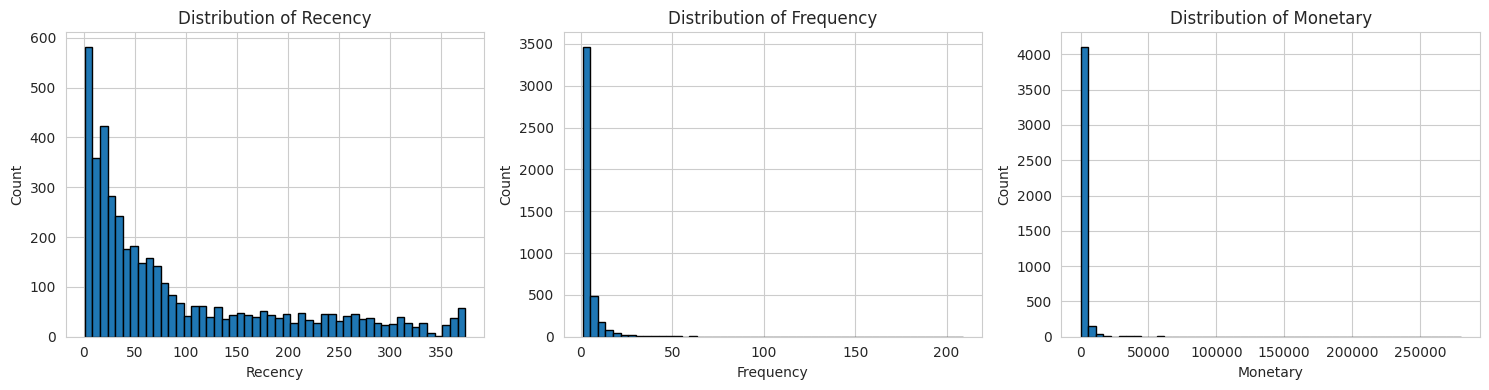

In [113]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# What do you see in these distributions?
#--> highly right skewed distribution
# Are there outliers? How will they affect clustering?
#--> yes there are outliers, the outliers are pulling the distribution to right especially so for frequency
# and monetary


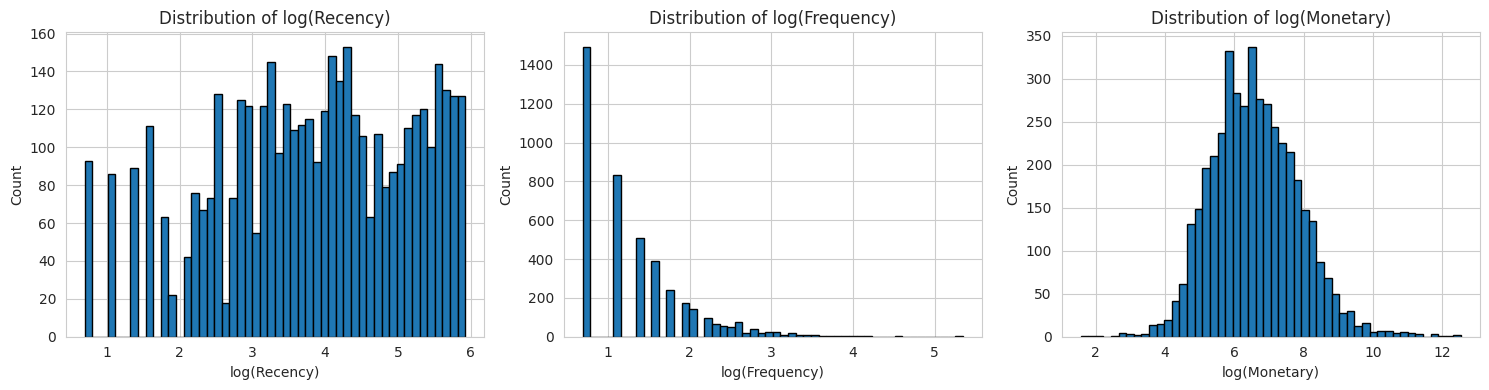

In [114]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decide how to handle outliers in each feature
# Options: cap at percentile, log transform, remove, keep
# Justify your choice for EACH feature in comments
# --> since all three are right skewed log transformation to compress the range and handle outliers without data loss

customer_df_log = customer_df.copy()
features=['Recency', 'Frequency', 'Monetary']
for feat in features:
    customer_df_log[feat] = np.log1p(customer_df_log[feat])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(features):
    axes[i].hist(customer_df_log[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of log({feat})')
    axes[i].set_xlabel(f'log({feat})')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [115]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? Answer in a comment before scaling.
#scaling is necessary because the feature like monetary which have extremely large numbers compared to
# other features influences distance basked algorithm like k-means

# Apply StandardScaler
scaler = StandardScaler()


# Fit and transform the feature matrix
# Store scaled features as X_scaled (numpy array) and X_scaled_df (DataFrame)
X = customer_df_log[['Recency', 'Frequency', 'Monetary']]

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=customer_df.index)

# Verify scaling worked
verification_df = pd.DataFrame({
    'Mean': X_scaled.mean(axis=0),
    'Std': X_scaled.std(axis=0)
}, index=features)

verification_df
# standardscaler is working since the mean are close to 0 and std =1
#display(X_scaled_df.describe())


,Mean,Std
Recency,-9.172520e-17,1.0
Frequency,-7.206980e-17,1.0
Monetary,9.172520e-17,1.0


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


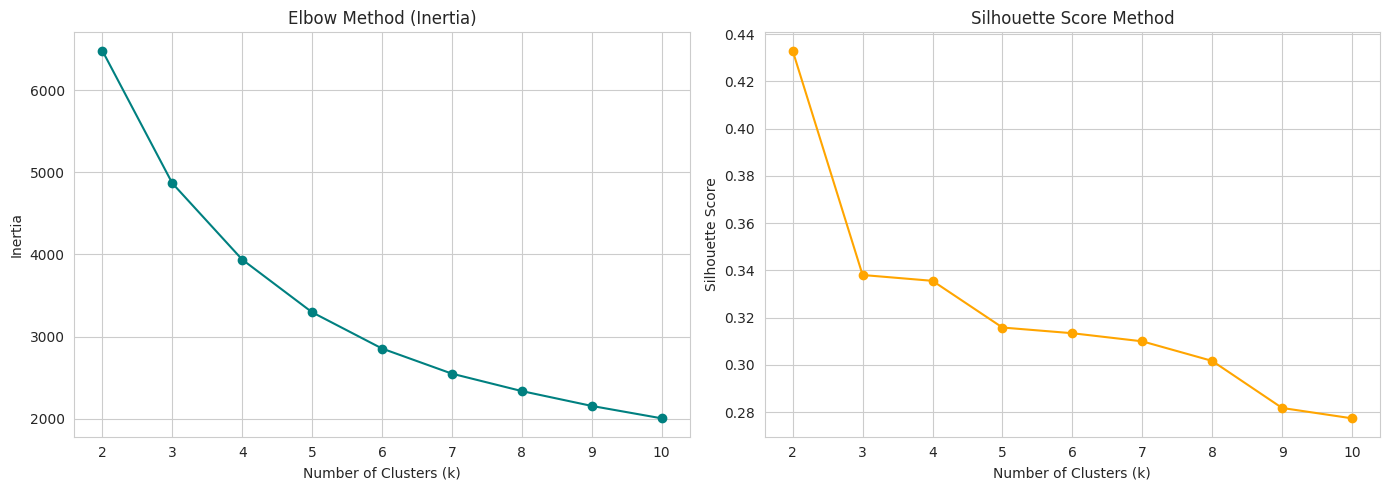

In [132]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    # Initialize and fit KMeans
    kmeans = KMeans(n_clusters=k, init='random', random_state=42)
    kmeans.fit(X_scaled)

    # Append inertia
    inertias.append(kmeans.inertia_)

    # Append silhouette score
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Elbow Curve and Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method Plot
axes[0].plot(k_range, inertias, marker='o', color='teal')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

# Silhouette Score Plot
axes[1].plot(k_range, silhouette_scores, marker='o',  color='orange')
axes[1].set_title('Silhouette Score Method')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# What k did you choose? Why?
# --> chose k=3. While k=2 has a higher silhouette score, k=3 provides a more nuanced
# segmentation for business use, and it sits right at the elbow of the inertia plot.

In [133]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++

OPTIMAL_K = 3
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

kmeans = KMeans(n_clusters=k, init='random', random_state=42)

for i in range(N_RUNS):
    # Random init - use different random_state for each run to see variation
    km_random = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i)
    km_random.fit(X_scaled)
    random_inertias.append(km_random.inertia_)

    # K-Means++ init
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# YOUR OBSERVATION HERE (as a comment):
# K-Means++ is generally more stable (lower std) and tends to find lower inertia
# values faster than random initialization.

Random Init Inertias: [4868.07, 4868.15, 4867.77, 4868.07, 4867.9]
K-Means++ Init Inertias: [4867.99, 4868.07, 4868.05, 4868.1, 4868.1]

Random std: 0.14
K-Means++ std: 0.04


In [134]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k
final_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
final_kmeans.fit(X_scaled)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = final_kmeans.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
# Add count to see cluster size
kmeans_profile['Count'] = customer_df['KMeans_Cluster'].value_counts()

print("K-Means Cluster Profiles:")
display(kmeans_profile)

K-Means Cluster Profiles:


,Recency,Frequency,Monetary,Count
KMeans_Cluster,,,,
0,44.46,3.37,1257.70,1696
1,17.07,13.27,7865.64,776
2,167.61,1.35,361.54,1866


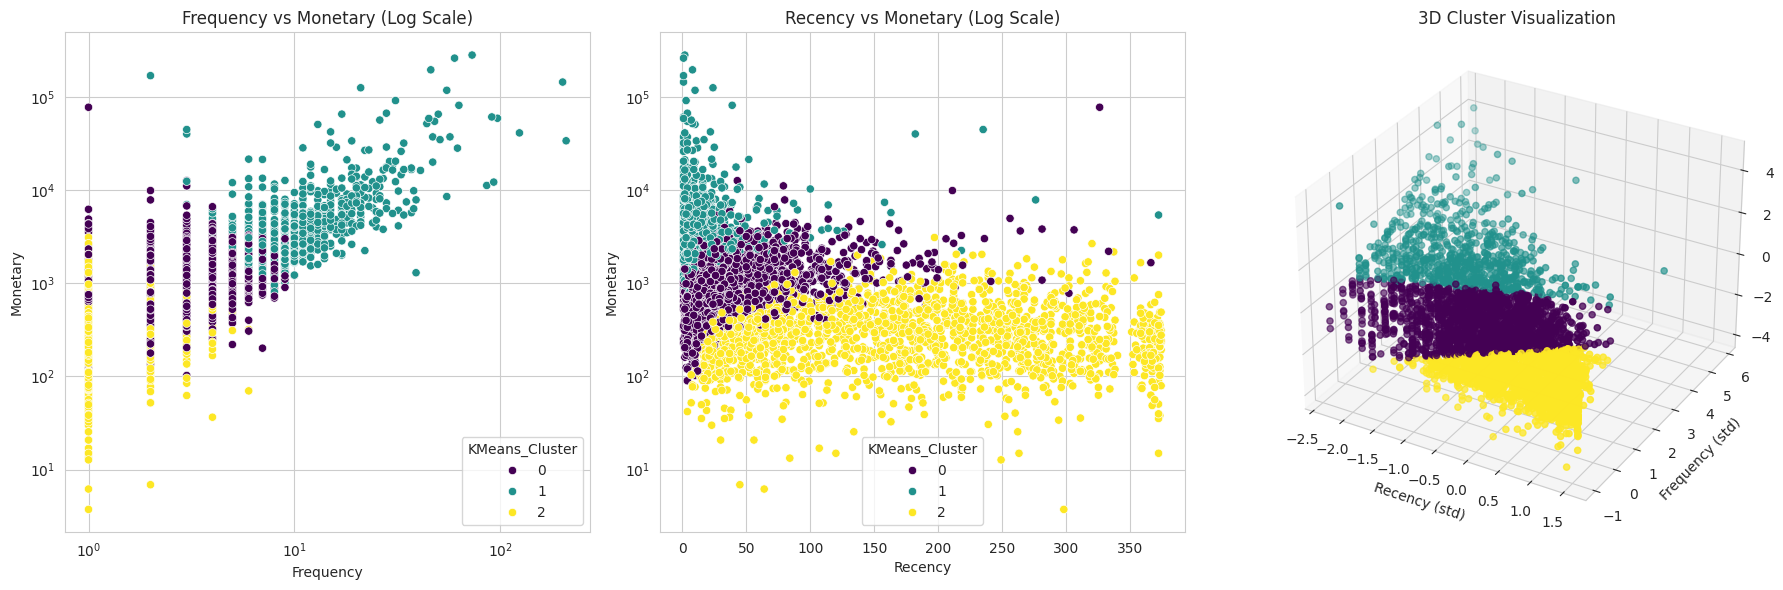

In [135]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
fig = plt.figure(figsize=(18, 6))

# 1. Frequency vs Monetary
ax1 = fig.add_subplot(131)
sns.scatterplot(data=customer_df, x='Frequency', y='Monetary', hue='KMeans_Cluster',
                palette='viridis', ax=ax1)
ax1.set_title('Frequency vs Monetary (Log Scale)')
ax1.set_yscale('log')
ax1.set_xscale('log')

# 2. Recency vs Monetary
ax2 = fig.add_subplot(132)
sns.scatterplot(data=customer_df, x='Recency', y='Monetary', hue='KMeans_Cluster',
                palette='viridis', ax=ax2)
ax2.set_title('Recency vs Monetary (Log Scale)')
ax2.set_yscale('log')

# 3. 3D Plot of Scaled Features
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
            c=customer_df['KMeans_Cluster'], cmap='viridis', s=20)
ax3.set_xlabel('Recency (std)')
ax3.set_ylabel('Frequency (std)')
ax3.set_zlabel('Monetary (std)')
ax3.set_title('3D Cluster Visualization')

plt.tight_layout()
plt.show()

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


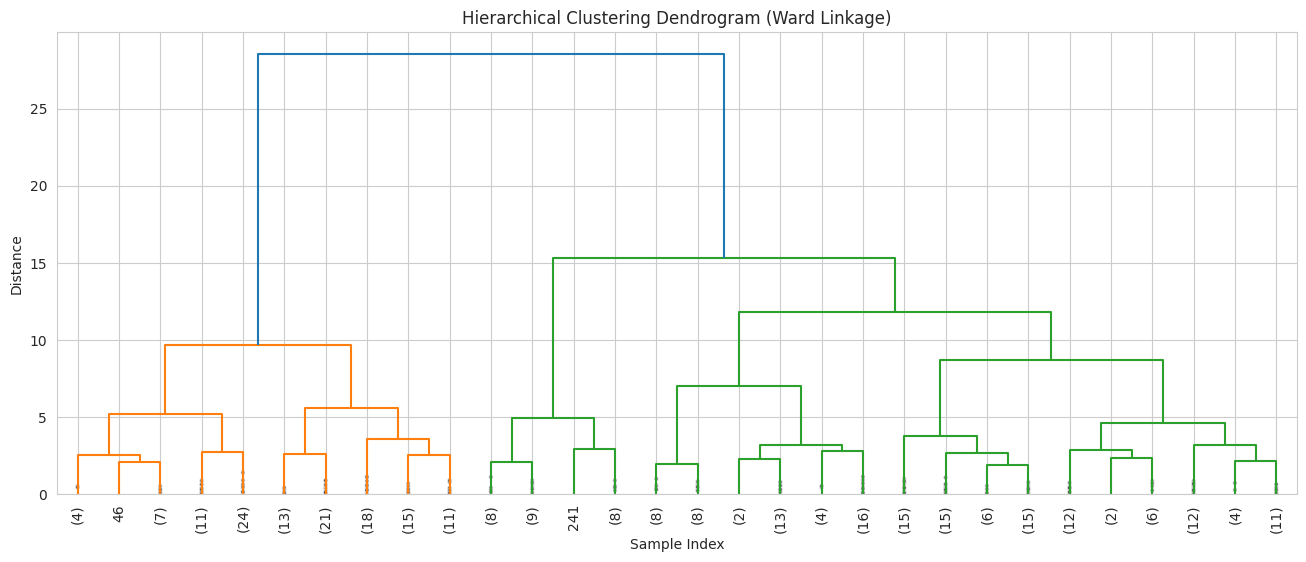

In [136]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment

SAMPLE_SIZE = 300  # adjust if needed
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# Where did you cut the dendrogram? Why? --> at 15 Euclidian distance
# How many clusters does this suggest? --> 3 clusters

In [137]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER = 3

# Ward linkage
ward_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
ward_labels = ward_model.fit_predict(X_scaled)

# Second linkage method (complete, average, or single)
complete_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
alt_labels = complete_model.fit_predict(X_scaled)

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = ward_labels
customer_df['Hierarchical_Alt'] = alt_labels

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("Alternative (Complete) linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# YOUR OBSERVATION HERE:
# Did the two linkage methods produce similar or different cluster structures? ->different
# Which do you prefer and why? -> ward because it evaluates overall variance and is more robust to outliers

Ward linkage cluster sizes:
Hierarchical_Ward
0    2410
1    1016
2     912
Name: count, dtype: int64
Alternative (Complete) linkage cluster sizes:
Hierarchical_Alt
0    2575
2    1729
1      34
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):


,Recency,Frequency,Monetary,Count
Hierarchical_Ward,,,,
0,65.42,2.49,855.47,2410
1,21.60,11.20,6511.38,1016
2,243.21,1.27,256.79,912


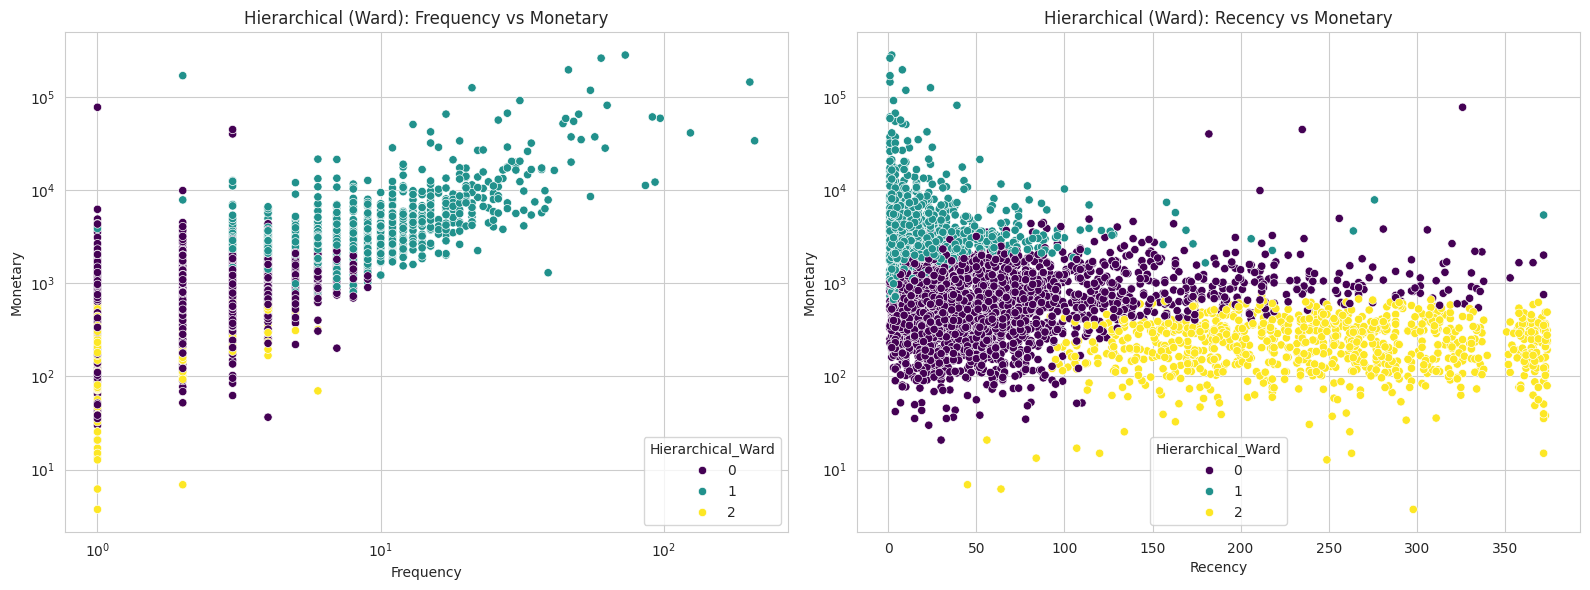

In [138]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
hier_profile['Count'] = customer_df['Hierarchical_Ward'].value_counts()

print("Hierarchical Clustering Profiles (Ward):")
display(hier_profile)

# ── Visualise — same axes as K-Means for comparison ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Frequency vs Monetary (Ward)
sns.scatterplot(data=customer_df, x='Frequency', y='Monetary', hue='Hierarchical_Ward',
                palette='viridis', ax=ax1)
ax1.set_title('Hierarchical (Ward): Frequency vs Monetary')
ax1.set_yscale('log')
ax1.set_xscale('log')

# 2. Recency vs Monetary (Ward)
sns.scatterplot(data=customer_df, x='Recency', y='Monetary', hue='Hierarchical_Ward',
                palette='viridis', ax=ax2)
ax2.set_title('Hierarchical (Ward): Recency vs Monetary')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


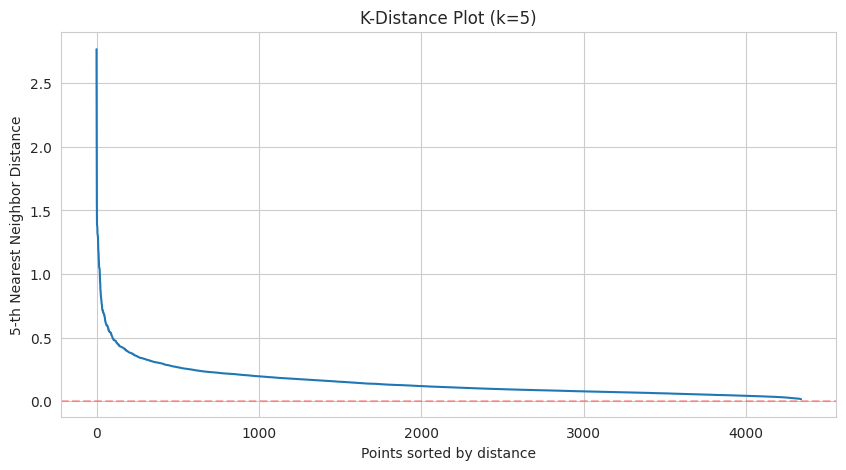

In [139]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# YOUR OBSERVATION HERE:
# Where is the elbow in this plot? -->0.5
# What epsilon value does it suggest? -->0.5
EPSILON_ESTIMATE = 0.5# YOUR CHOICE HERE


In [140]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
experiments = [
    {'eps': EPSILON_ESTIMATE*0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE *1.2, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE, 'min_samples': 10}
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# I will choose eps=0.5 and min_samples=5 as it captures the main structure without excessive noise
FINAL_EPS = 0.5
FINAL_MIN_SAMPLES = 5

 eps  min_samples  n_clusters  n_noise  noise_pct
 0.4            5           6      101       2.33
 0.5            5           2       62       1.43
 0.6            5           2       33       0.76
 0.5           10           2       79       1.82


In [141]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print("\nNote: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nNoise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# YOUR INTERPRETATION HERE:
# Who are these noise customers?
# Are they outliers (e.g. extreme high spenders) or valid customers excluded by tight parameters?
#--> by looking at the monetary axis we can conclude most of them are extreme high spenders
# What would you recommend to the business about these customers? -->to look out after them and appoint serpearte account management team as they are extremely high paying customers


DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    2791
 1    1485
-1      62
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 62 (1.4%)

Noise customer profile (mean RFM):
       Recency  Frequency   Monetary
count    62.00      62.00      62.00
mean     54.56      33.21   43874.28
std      92.06      43.33   59503.78
min       1.00       1.00       3.75
25%       3.00       3.25    5595.32
50%       9.00      15.50   28227.21
75%      50.25      49.50   57946.04
max     372.00     209.00  280206.02


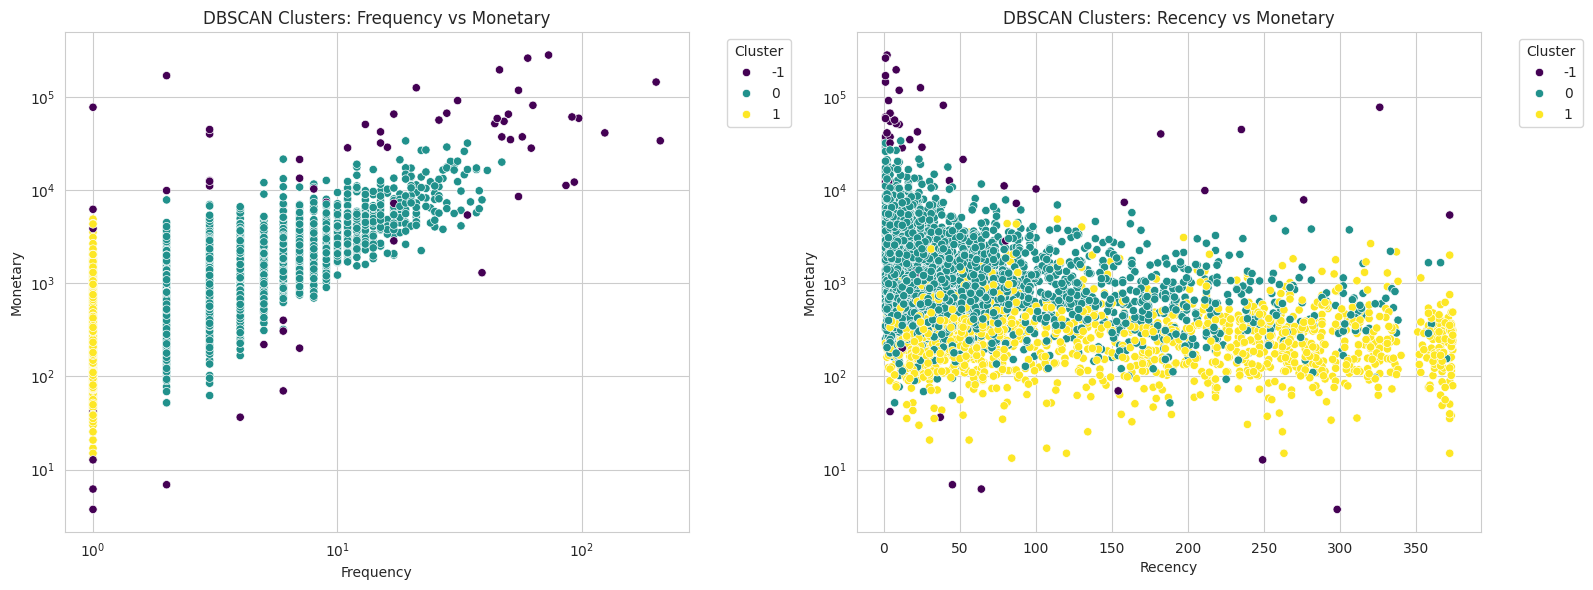

In [142]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
fig,(ax1,ax2)=plt.subplots(1,2, figsize=(16,6))

#frequency vs monetary
sns.scatterplot(data=customer_df, x='Frequency', y='Monetary', hue='DBSCAN_Cluster', palette='viridis', ax=ax1)
ax1.set_title('DBSCAN Clusters: Frequency vs Monetary')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc=2)

#recency vs monetary
sns.scatterplot(data=customer_df, x='Recency', y='Monetary', hue='DBSCAN_Cluster', palette='viridis', ax=ax2)
ax2.set_title('DBSCAN Clusters: Recency vs Monetary')
ax2.set_yscale('log')
ax2.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc=2)

plt.tight_layout()
plt.show()


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [143]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
dbscan_mask = customer_df['DBSCAN_Cluster'] != -1
X_scaled_no_noise = X_scaled[dbscan_mask] #identify outliers and filter them out
dbscan_labels = customer_df.loc[dbscan_mask, 'DBSCAN_Cluster']

sil_dbscan = silhouette_score(X_scaled_no_noise, dbscan_labels)
db_dbscan = davies_bouldin_score(X_scaled_no_noise, dbscan_labels)
ch_dbscan = calinski_harabasz_score(X_scaled_no_noise, dbscan_labels)

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [len(np.unique(kmeans_labels)), len(np.unique(hier_labels)), len(np.unique(dbscan_labels))],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4)],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2)]
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")

             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           3            0.3360                1.0492                  3627.05
Hierarchical (Ward)           3            0.2666                1.0124                  2955.79
             DBSCAN           2            0.2931                1.0633                  2391.06

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Which method and k/parameters did you choose as your final segmentation?**  
> I chose **K-Means with (k=3)**. It  provided the best balance between statistical validity and business interpretability.

**What do the validation metrics tell you?**  
> K-Means achieved the highest **Silhouette Score (0.3360)** and **Calinski-Harabasz Index (3627.05)**, indicating that the clusters are both dense and well-separated.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
> There was a slight conflict: Davies-Bouldin index preferred the Hierarchical model, but Silhouette and CH preferred K-Means. I chose K-Means because it provided more balanced cluster sizes for marketing purposes.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
> K-Means clearly separated customers into three actionable tiers:
1. **Champions (Cluster 1):** Frequent, high-spending, recent buyers.
2. **Average Joes (Cluster 0):** Moderate activity.
3. **Hibernating (Cluster 2):** High recency (haven't visited in a long time) and low spend.

## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English


- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster


> Cluster 1 (Champions): Your most valuable customers. High spend, high frequency, and very recent. Action: VIP loyalty programs.

> Cluster 0 (Steady Shoppers): Moderate spend and frequency. They are still active but could be encouraged to buy more. Action: Cross-selling or 'buy more, save more' offers.

> Cluster 2 (At-Risk Dormants): Low spenders who haven't visited in nearly 6 months. Action: Win-back campaigns or 'We miss you' discount codes.
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.

>

In [144]:
# ── Final Business Profile Calculation ───────────────────────────────────────
# This gives you the exact numbers of RMF values

final_summary = customer_df.groupby('KMeans_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer ID': 'count'
}).rename(columns={'Customer ID': 'Count'}).round(1)

print("Final Business Profiles for Narrative Development:")
display(final_summary)

Final Business Profiles for Narrative Development:


,Recency,Frequency,Monetary,Count
KMeans_Cluster,,,,
0,44.5,3.4,1257.7,1696
1,17.1,13.3,7865.6,776
2,167.6,1.3,361.5,1866


### Cluster Profiles

**Cluster 1 — Champions (The VIPs)**  
_Profile:_ Our most active and valuable segment. These **776** customers shop frequently  and have visited very recently (mean recency 17 days).

_Marketing Action:_ Enroll in an exclusive VIP loyalty program with early access to new products.

**Cluster 0 — Steady Shoppers (The Mid-Tier)**  
_Profile:_ A solid base of **1,696** customers who shop semi-regularly. They are still relatively active (mean recency 44 days).

_Marketing Action:_ Use personalized cross-selling and 'bundle' offers to increase their average basket size.

**Cluster 2 — At-Risk (Hibernating)**  
_Profile:_ The largest group (**1,866** customers) with very low engagement. They typically only purchased once and haven't returned in nearly 6 months (mean recency 167 days).

_Marketing Action:_ Triggered 'Win-back' email campaigns with a high-value discount to re-activate them.

### Executive Summary (200–300 words)

[USER: WRITE YOUR SUMMARY HERE BASED ON THE ABOVE PROFILES]
> To optimize our marketing efficiency and customer retention, we performed an unsupervised machine learning analysis on our 2010-2011 transaction data. By applying **RFM Analysis** (Recency, Frequency, Monetary value) and the **K-Means clustering** algorithm which we identified as the best algorithm for our task in hand, using kmeans algorithm we identified three distinct customer segments with differnt buying power frequency and recency that require unique strategic approaches. they are as follows:

1.  **Champions (18% of base):** These high-value customers are the engine of our revenue. They visit every two weeks and spend an average of over £7,000. They are highly active and represent our most loyal advocates.
2.  **Steady Shoppers (39% of base):** This 'middle class' of customers shops semi-regularly but lacks the high-frequency loyalty of the Champions. With a mean recency of 44 days, they are still reachable and represent the best opportunity for revenue growth through cross-selling.
3.  **At-Risk/Hibernating (43% of base):** Our largest group consists of one-time or low-frequency shoppers who haven't returned in nearly 6 months.

**Strategic Recommendation**
We recommend shifting away from 'one-size-fits-all' promotions toward a tiered communication strategy. By rewarding **Champions** with VIP status, we protect our core revenue. Simultaneously, by targeting **At-Risk** customers with aggressive re-activation discounts, we can salvage customer lifetime value before total churn. Furthermore, we identified **1.4% of the base as extreme outliers**; these customers should be handled by a dedicated account management team rather than automated marketing, as their purchasing patterns are non-standard. Implementing this segmented approach will allow for more efficient allocation of marketing budgets and higher conversion rates.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.


**Failed Hypothesis 1: Optimal K Selection**  
- *What I expected:* I expected the Elbow Method and Silhouette Score to point clearly to the same 'k' value.
- *What happened:* The Silhouette Score peaked sharply at k=2, while the Elbow Method suggested k=3.
- *What I learned:* Statistical metrics can conflict. While k=2 was 'cleaner' mathematically, k=3 made much more sense to me more so after plotting the clusters

**Failed Hypothesis 2: Hierarchical Linkage Choice**  
- *What I expected:* I expected 'Complete' linkage to produce balanced clusters similar to 'Ward' linkage.
- *What happened:* Complete linkage produced one giant cluster and one tiny cluster of only 34 customers, making it useless for marketing.
- *What I learned:* 'Ward' is much more robust from outiler for RFM data because it minimizes variance within clusters, whereas 'Complete' linkage is too sensitive to the maximum distance between points.

**Failed Hypothesis 3: Initial DBSCAN Visualization**  
- *What I expected:* I expected a standard scatter plot to clearly show the density-based clusters.
- *What happened:* The first attempt resulted in a `ValueError` because I tried to map a cluster column that hadn't been assigned yet, and later attempts failed to show all axes because the subplot handles weren't correctly managed.
- *What I learned:* DBSCAN requires careful data handling because it produces noise labels (-1) that must be accounted for specifically in both validation metrics and visualization logic.

## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [145]:
# High Ceiling Work — YOUR CODE HERE
# Ill come back to it later 😅